# Energy Balance Model: Grey Atmosphere Radiation Model

This notebook extends our classwork on radiative energy balance by using `climlab` to simulate how a grey atmosphere evolves toward equilibrium.

## What you should learn
- How a vertical temperature profile and an absorptivity profile affect outgoing longwave radiation
- How to diagnose radiative imbalance using $ASR - OLR$
- How a simple 2-layer model compares with a more realistic 10-layer model
- How the system approaches radiative equilibrium over time

## How to use this notebook
1. Read each markdown cell before running the code below it.
2. Predict what should happen before you execute a model experiment.
3. Compare your prediction with the plotted results.
4. Answer the exercise questions as you move through the notebook.

Below we import the packages needed for the calculations, data handling, and plotting.

In [1]:
%matplotlib inline

import warnings

import climlab
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# Keep notebook output focused on the model results rather than library warnings.
warnings.filterwarnings('ignore')

## Part 1: 2-Layer Radiative Balance Model

We begin with a highly simplified atmosphere that has only two layers. This is close to the kind of hand calculation we can do on paper, but now we let the model step forward in time.

In this section we will:
- set the initial surface and atmospheric temperatures
- prescribe a longwave absorptivity for each layer
- integrate the model for many days
- examine whether the column gains or loses energy

### Before you run the code
Make a prediction:
- If the atmosphere absorbs more longwave radiation, should $OLR$ increase quickly or decrease at first?
- If $ASR - OLR \neq 0$, what must happen to temperature over time?

The code cell below sets the initial state for the model.

In [2]:
# Create a grey-radiation column with 2 atmospheric layers.
col = climlab.GreyRadiationModel(num_lev=2)

# Set the initial temperatures.
# Ts is the surface temperature and Tatm contains the atmospheric layer temperatures.
col.Ts[:] = 288.
col.Tatm[:] = np.array([280, 275])

# Choose how long to integrate the model forward in time.
num_days = 300

# Access the longwave radiative transfer subprocess and prescribe absorptivity.
LW = col.subprocess['LW']
LW.absorptivity = np.array([0.59, 0.59])

# Compute diagnostic quantities once so we can inspect the initial state.
col.compute_diagnostics()

### Evolving the Column in Time

The next cell advances the model one day at a time and stores both state variables and radiative diagnostics.

As you read the code, focus on three questions:
- Which variables describe the temperature state of the system?
- Which variables diagnose the radiative fluxes?
- How will we tell from the results whether the column is approaching equilibrium?

A system in radiative equilibrium should satisfy

$$
ASR - OLR \approx 0
$$

so we will track that quantity carefully.

In [3]:
# Lists that will store the model state and diagnostic output at each timestep.
diagnostics_arr = []
state_arr = []

# Radiative quantities we want to track explicitly.
OLR = []
ASR = []
LW_absorbed_atm = []
SW_up_TOA = []

# Step the model forward one day at a time.
for day in range(num_days):
    col.compute_diagnostics()
    diag = climlab.to_xarray(col.diagnostics)
    st = climlab.to_xarray(col.state).copy(deep=True)

    # Save key diagnostics that are useful for interpreting the energy budget.
    ASR.append(col.ASR[0])
    OLR.append(col.OLR[0])
    LW_absorbed_atm.append(col.LW_absorbed_atm[0])
    SW_up_TOA.append(col.SW_up_TOA[0])

    diagnostics_arr.append(diag)
    state_arr.append(st)

    # Advance the column by one timestep.
    col.step_forward()

print(len(ASR), len(OLR))

# Build a time coordinate for the saved results.
time_dim = pd.RangeIndex(start=0, stop=col.time['days_elapsed'], step=1, name='day')

# Concatenate the saved diagnostics and state variables into xarray objects.
diagnostics_xr = xr.concat(diagnostics_arr, dim=time_dim, compat='equals')
state_xr = xr.concat(state_arr, dim=time_dim)

# Merge state and diagnostics into one dataset and add the fluxes we stored manually.
model_results = xr.merge([diagnostics_xr, state_xr])
model_results = model_results.assign({'OLR': (('day',), np.asarray(OLR))})
model_results = model_results.assign({'ASR': (('day',), np.asarray(ASR))})

model_results

300 300


<xarray.Dataset> Size: 79kB
Dimensions:            (day: 300, depth: 1, lev: 2, depth_bounds: 2,
                        lev_bounds: 3)
Coordinates:
  * depth              (depth) float64 8B 0.5
  * lev                (lev) float64 16B 250.0 750.0
  * depth_bounds       (depth_bounds) float64 16B 0.0 1.0
  * lev_bounds         (lev_bounds) float64 24B 0.0 500.0 1e+03
  * day                (day) int64 2kB 0 1 2 3 4 5 6 ... 294 295 296 297 298 299
Data variables: (12/26)
    flux_from_sfc      (day, depth) float64 2kB 541.6 541.6 ... 541.6 541.6
    flux_to_sfc        (day, depth) float64 2kB 541.6 541.6 ... 541.6 541.6
    flux_to_space      (day, depth) float64 2kB 341.4 341.4 ... 341.4 341.4
    absorbed           (day, lev) float64 5kB -0.0247 -0.02148 ... -0.02148
    absorbed_total     (day, depth) float64 2kB -0.04618 -0.04618 ... -0.04618
    emission           (day, lev) float64 5kB 100.1 159.2 100.1 ... 100.1 159.2
    ...                 ...
    planetary_albedo   (day, depth) float64 2kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    LW_emission        (day, lev) float64 5kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    LW_absorbed_atm    (day, lev) float64 5kB -0.0247 -0.02148 ... -0.02148
    SW_absorbed_atm    (day, lev) float64 5kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Ts                 (day, depth) float64 2kB 288.0 290.6 ... 296.7 296.7
    Tatm               (day, lev) float64 5kB 280.0 275.0 276.6 ... 233.9 262.7

## Interpreting the 2-Layer Model Output

The first plot shows how the temperatures of the two atmospheric layers and the surface evolve in time. The second plot shows the radiative imbalance, $ASR - OLR$.

### What to look for
- If $ASR - OLR > 0$, the column is gaining energy.
- If $ASR - OLR < 0$, the column is losing energy.
- As the model approaches equilibrium, the imbalance should move toward zero.

### Exercise 1
Answer these after running the next plot:
1. Does the surface warm or cool during the first part of the simulation?
2. Which reaches a steadier value first: the radiative imbalance or the temperatures?
3. What evidence suggests that the column is approaching equilibrium?

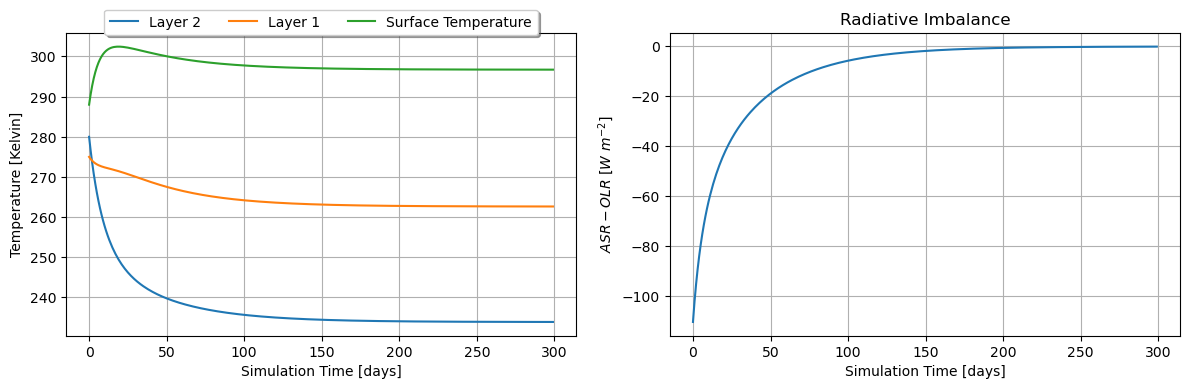

In [4]:
# Plot temperature evolution and radiative imbalance for the 2-layer model.
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))

plt.axes(ax[0])
plt.plot(model_results.day, model_results['Tatm'], label=['Layer 2', 'Layer 1'])
plt.plot(model_results.day, model_results['Ts'], label='Surface Temperature')
plt.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, 1.1),
          ncol=3, fancybox=True, shadow=True)
plt.xlabel('Simulation Time [days]')
plt.ylabel('Temperature [Kelvin]')
plt.title('Temperature Adjustment')
plt.grid()

plt.axes(ax[1])
plt.plot(model_results.day, model_results['ASR'] - model_results['OLR'])
plt.ylabel('$ASR-OLR$ [$W\ m^{-2}$]')
plt.title('Radiative Imbalance')
plt.xlabel('Simulation Time [days]')
plt.grid()

plt.tight_layout()
plt.show()

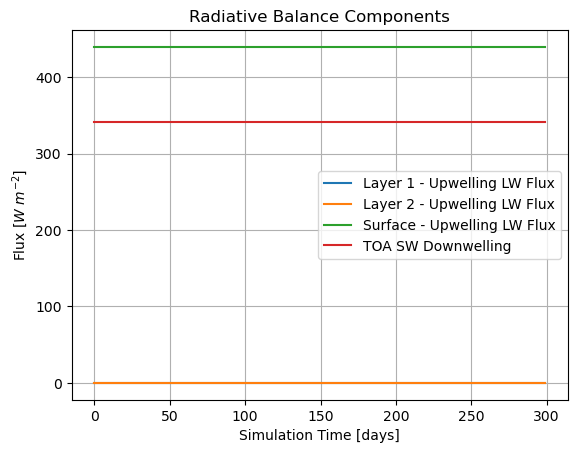

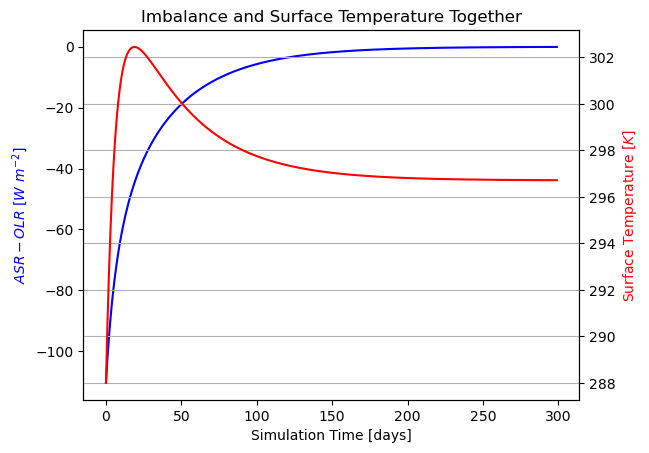

In [5]:
# Plot individual radiative components to see which fluxes change as the column evolves.
model_results['LW_emission'][:, 0].plot(label='Layer 1 - Upwelling LW Flux')
model_results['LW_emission'][:, 1].plot(label='Layer 2 - Upwelling LW Flux')
model_results['LW_up_sfc'].T.plot(label='Surface - Upwelling LW Flux')
model_results['SW_down_TOA'].T.plot(label='TOA SW Downwelling')

plt.grid()
plt.ylabel('Flux [$W\ m^{-2}$]')
plt.title('Radiative Balance Components')
plt.xlabel('Simulation Time [days]')
plt.legend()
plt.show()

# Compare radiative imbalance directly against surface temperature.
plt.plot(model_results.day, model_results['ASR'] - model_results['OLR'], 'b')
plt.ylabel('$ASR-OLR$ [$W\ m^{-2}$]', color='b')
plt.xlabel('Simulation Time [days]')
plt.twinx()
plt.plot(model_results.day, model_results['Ts'], 'r-')
plt.ylabel('Surface Temperature [$K$]', color='r')
plt.grid()
plt.title('Imbalance and Surface Temperature Together')
plt.show()

### Exercise 2: Connect the Plots to the Energy Budget

Use the figures above to answer:
1. When the surface temperature rises, what happens to $OLR$?
2. Why does a decreasing radiative imbalance often accompany a slowing rate of temperature change?
3. Which flux in the radiative component plot seems most closely tied to the surface temperature evolution?

Optional extension:
- Change the two-layer absorptivity from `0.59` to a smaller value and rerun Part 1.
- Predict first: should the equilibrium surface temperature become warmer or cooler?

## Part 2: 10-Layer Radiative Balance Model

A 2-layer atmosphere is useful for understanding the main ideas, but it cannot represent much vertical structure. In this section we increase the model resolution to 10 layers.

This allows us to ask new questions:
- How does the temperature response vary with height?
- Does the column still move toward equilibrium?
- What extra insight do we gain from having more layers?

### Before you run the next code cell
Predict whether a 10-layer atmosphere should:
1. reach equilibrium faster or slower than the 2-layer case,
2. show more vertical structure in temperature change,
3. produce a smoother or noisier evolution of the fluxes.

In [6]:
# Create a grey-radiation column with 10 atmospheric layers.
col = climlab.GreyRadiationModel(num_lev=10)

# Set the initial temperature profile.
col.Ts[:] = 288.
col.Tatm[:] = np.linspace(288, 236, 10)

# Integrate for a shorter period than before because there are more layers to inspect.
num_days = 250

# Prescribe a uniform longwave absorptivity profile.
LW = col.subprocess['LW']
LW.absorptivity = 0.18 * np.ones(10)
col.compute_diagnostics()

# Store model output through time.
diagnostics_arr = []
state_arr = []

OLR = []
ASR = []
LW_absorbed_atm = []
SW_up_TOA = []

for day in range(num_days):
    col.compute_diagnostics()
    diag = climlab.to_xarray(col.diagnostics)
    st = climlab.to_xarray(col.state).copy(deep=True)

    OLR.append(col.OLR[0])
    ASR.append(col.ASR[0])
    LW_absorbed_atm.append(col.LW_absorbed_atm[0])
    SW_up_TOA.append(col.SW_up_TOA[0])

    diagnostics_arr.append(diag)
    state_arr.append(st)

    col.step_forward()

# Create the time coordinate.
time_dim = pd.RangeIndex(start=0, stop=col.time['days_elapsed'], step=1, name='day')

# Convert the saved model output into xarray datasets.
diagnostics_xr = xr.concat(diagnostics_arr, dim=time_dim, compat='equals')
state_xr = xr.concat(state_arr, dim=time_dim)

# Merge everything into one dataset for analysis.
model_results = xr.merge([diagnostics_xr, state_xr])
model_results = model_results.assign({'OLR': (('day',), np.asarray(OLR))})
model_results = model_results.assign({'ASR': (('day',), np.asarray(ASR))})

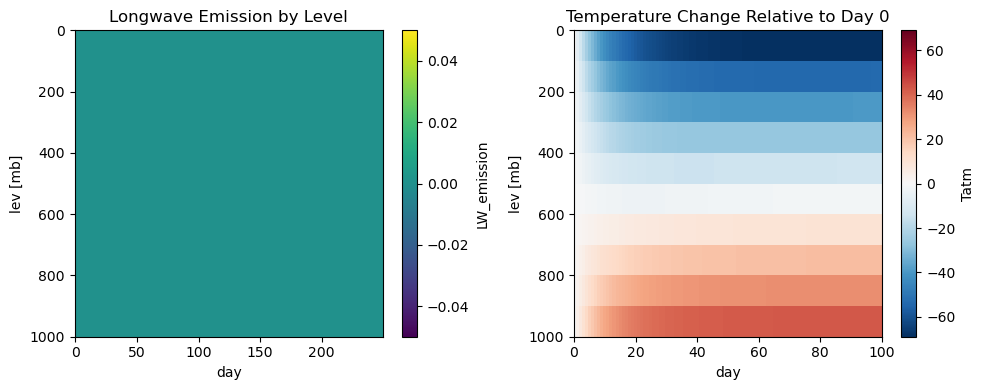

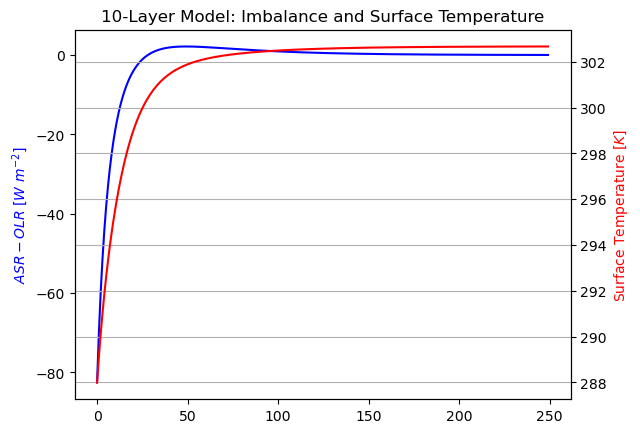

In [7]:
# Visualize flux evolution and temperature change with height.
# The second panel shows temperature change relative to the initial atmospheric profile.
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

model_results['LW_emission'].T.plot(ax=axs[0])
axs[0].set_ylim(1000, 0)
axs[0].set_title('Longwave Emission by Level')

tatm_diff = model_results['Tatm'] - model_results['Tatm'][0, :]
tatm_diff.T.plot(ax=axs[1], cmap='RdBu_r')
axs[1].set_ylim(1000, 0)
axs[1].set_xlim(0, 100)
axs[1].set_title('Temperature Change Relative to Day 0')

plt.tight_layout()
plt.show()

# As before, compare the energy imbalance with the surface temperature response.
plt.plot(model_results.day, model_results['ASR'] - model_results['OLR'], 'b')
plt.ylabel('$ASR-OLR$ [$W\ m^{-2}$]', color='b')
plt.twinx()
plt.plot(model_results.day, model_results['Ts'], 'r-')
plt.ylabel('Surface Temperature [$K$]', color='r')
plt.grid()
plt.xlabel('Simulation Time [days]')
plt.title('10-Layer Model: Imbalance and Surface Temperature')
plt.show()

## Student Exercises and Extensions

### Exercise 3: Compare the 2-layer and 10-layer experiments
1. Which model gives you more information about how warming or cooling varies with height?
2. In which model is it easier to connect the results directly to hand calculations from class?
3. Does the sign of $ASR - OLR$ explain the direction of surface temperature change in both experiments?

### Exercise 4: Design your own experiment
Choose one modification below, predict the outcome, and then test it in the next code cell:
- increase the longwave absorptivity,
- decrease the surface starting temperature,
- change the vertical temperature profile,
- change the number of atmospheric layers.

For your write-up, include:
1. your prediction,
2. the code change you made,
3. the evidence from the plots,
4. a short explanation using energy balance language.

In [9]:
# Student sandbox: copy one of the model setups above, make one change, and test your prediction.
# Example ideas:
# - change LW.absorptivity
# - change the number of layers
# - change the initial temperature profile
# - compare how quickly equilibrium is reached

# Write your experiment here.